In [3]:
# This code uses the Weighted Balanced Truncation Method [PRE25, 112, 015302] for generating model reduction results
# Re-import necessary modules after code execution environment reset
import numpy as np
from scipy.linalg import cholesky, svd, eig
from scipy.linalg import svd, eig, cholesky, inv, expm
from scipy.special import expi, gamma, gammaincc

def WBT(s, w, x, p, T, method="TLBT", alpha=0.5, K=10.0):
    A = np.diag(-s)
    B = np.sqrt(w).reshape(-1, 1)
    C = B.T
    AA = s.reshape(-1, 1) + s
    EA = np.exp(-T * s)

    P = B @ B.T
    Q = C.T @ C

    if method == "classical":
        P = P / AA
        Q = Q / AA.T
    elif method == "TLBT":
        factor = (1 - np.outer(EA, EA)) / AA
        P = P * factor
        Q = Q * factor.T
    elif method == "WBT":
        if alpha == 0.5:
            EWA = np.exp(K * AA)
            ggt = expi((T + K) * AA)
            gg0 = expi(K * AA)
            P = P * EWA * (gg0 - ggt)
            Q = P.T
        else:
            a = 1 - 2 * alpha
            u1 = AA * K
            u2 = AA * (T + K)
            G1 = gammaincc(a, u1) * gamma(a)
            G2 = gammaincc(a, u2) * gamma(a)
            EWA = np.exp(AA * K)
            P = P * EWA * (G1 - G2) * (AA ** (2 * alpha - 1))
            Q = P.T
    else:
        raise ValueError("Unknown method")

    P += 1e-15 * np.eye(P.shape[0])
    Q += 1e-15 * np.eye(Q.shape[0])
    RP = cholesky(P, lower=True)
    RQ = cholesky(Q, lower=True)

    LL = RP.T @ RQ
    U, Sigma, _ = svd(LL)
    rel_sigma = Sigma[p] / Sigma[0] if p < len(Sigma) else 0.0

    Sigma_12 = np.diag(Sigma ** -0.5)
    Trans = RP @ U @ Sigma_12
    invT = inv(Trans)

    At = invT @ A @ Trans
    Bt = invT @ B
    Ct = C @ Trans

    Ad = At[:p, :p]
    Bd = Bt[:p]
    Cd = Ct[:, :p]

    d, V = eig(Ad)
    s_wbt = -d
    B_mr = np.linalg.solve(V, Bd)
    C_mr = Cd @ V
    w_wbt = (B_mr.flatten()) * (C_mr.flatten())

    x = x.reshape(-1, 1)
    y_original = np.sum(w * np.exp(-x @ s.reshape(1, -1)), axis=1)
    y_wbt = np.sum(w_wbt * np.exp(-x @ s_wbt.reshape(1, -1)), axis=1)

    error = np.abs(y_wbt - y_original)
    rerror = error / (np.abs(y_original) + 1e-15)
    merror = np.max(error)
    mrerror = np.max(rerror)

    return s_wbt, w_wbt, error, y_original, y_wbt, x.squeeze()



1.1254286382481798e-05


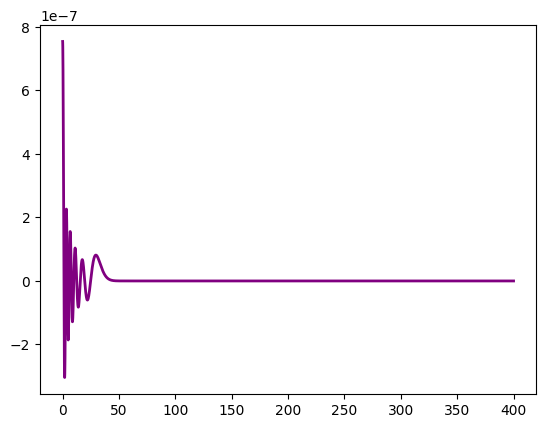

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# initialization
r = np.arange(1, 50.01, 0.01)
# std = cace_nnp.models[1].output_modules[1].shift_1.detach().numpy()
# beta = cace_nnp.models[1].output_modules[1].amplitude_1.detach().numpy()

std = [0.22209555, 0.3886948 , 0.5714464 , 0.7405551 , 0.8735464 ,
       0.98166317, 1.0816274 , 1.1881791 , 1.316837  , 1.4825934 ,
       1.6851343 , 1.9041564]
beta = [0.18407716, 0.30610022, 0.4257226 , 0.5521141 , 0.68409145,
       0.8108536 , 0.9288744 , 1.0501319 , 1.2014838 , 1.4234518 ,
       1.7152525 , 2.021375]

# compute w and s
w = np.array(beta) / (8 * np.pi**(3/2) * np.exp(3 * np.array(std)))
s = 2 * np.exp(std)

p = 1 / (s*s)

x = np.linspace(0, 400, 20000)

p_wbt, w_wbt, error, y_true, y_reduced, x_vals = WBT(p, w, x, p=5, T=400.0, method="TLBT")

s_wbt = np.sqrt(1/p_wbt)
print(np.linalg.norm(error))

# compute phi
phi = w[0] * np.exp(-x**2 / s[0]**2)
for i in range(1, 12):
    phi += w[i] * np.exp(-x**2 / s[i]**2)

# compute phi_new
phi_new = w_wbt[0] * np.exp(-x**2 / s_wbt[0]**2)
for i in range(1, 5):
    phi_new += w_wbt[i] * np.exp(-x**2 / s_wbt[i]**2)

plt.plot(x, phi-phi_new, label="$g_{\\theta_n}(r)$", linewidth=2, color='purple')

